In [11]:
import pathlib
import json

data = {
    "agent_penalty": [],
    "obstacle_penalty": [],
    "energy": [],
    "velocity_penalty": [],
    "num_robots": [],
    "sample_idx": [],
    "used_coarse_to_fine": [],
}

for result_dir in pathlib.Path("results").iterdir():
    if '=' not in result_dir.name:
        continue

    string = result_dir.name.split("=")[1]
    num_robots, sample_idx = string.split("_")
    summary = json.loads((result_dir / "summary.json").read_text())
    
    for used_coarse_to_fine, result in summary.items():
        result = result[0]
        data["agent_penalty"].append(result["agent_penalties"][0])
        data["obstacle_penalty"].append(result["obstacle_penalties"][0])
        data["energy"].append(result["energy_lowlevel"][0])
        data["velocity_penalty"].append(result["lowlevel_vel_penalties"])
        data["num_robots"].append(int(num_robots))
        data["sample_idx"].append(int(sample_idx))
        data["used_coarse_to_fine"].append(used_coarse_to_fine == "true")


In [12]:
import pandas as pd

data = pd.DataFrame(data)

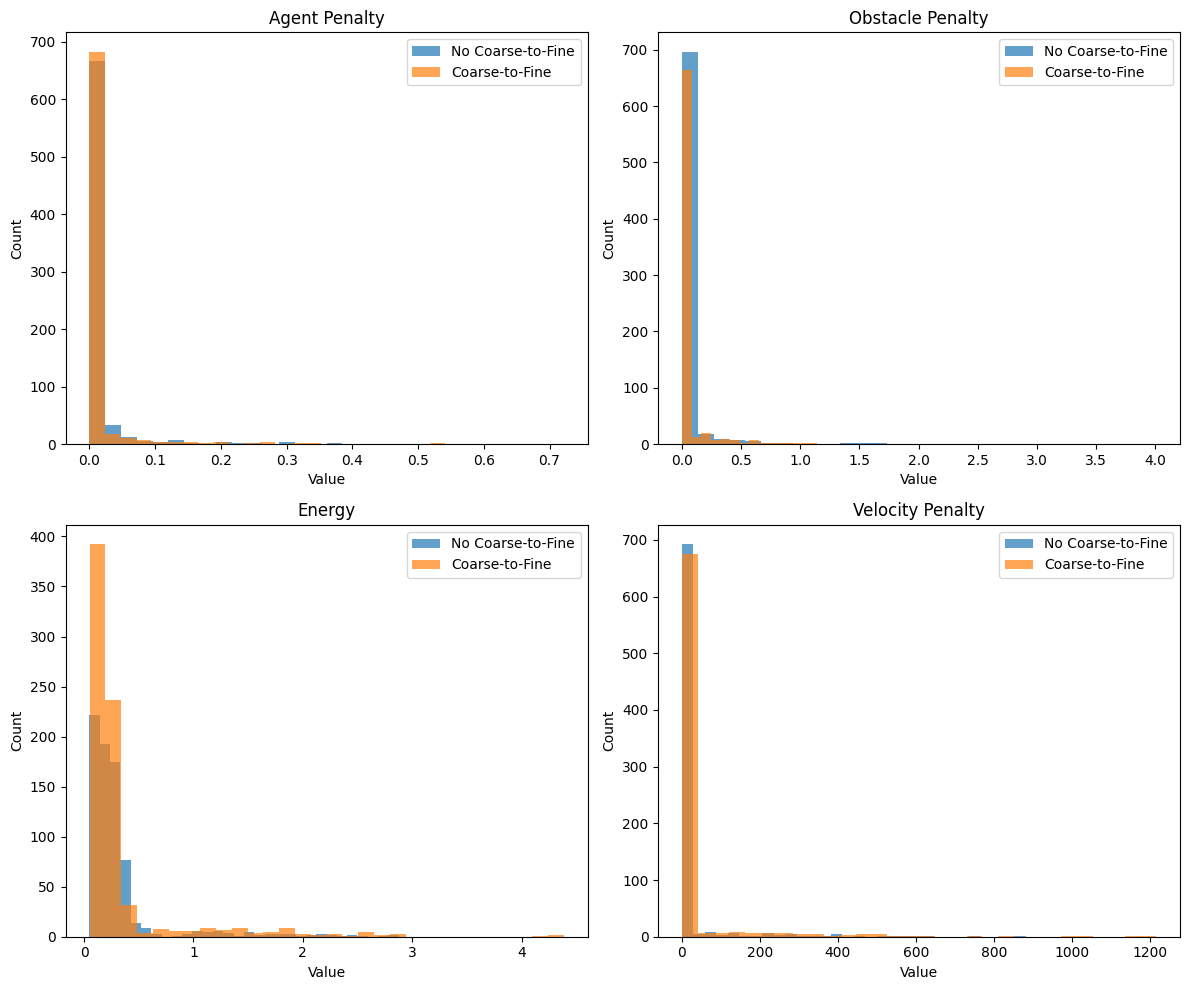

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Convert lists to numpy arrays for easier masking
agent_penalty = np.array(data["agent_penalty"])
obstacle_penalty = np.array(data["obstacle_penalty"])
energy = np.array(data["energy"])
velocity_penalty = np.array(data["velocity_penalty"])
used_ctf = np.array(data["used_coarse_to_fine"])

metrics = {
    "Agent Penalty": agent_penalty,
    "Obstacle Penalty": obstacle_penalty,
    "Energy": energy,
    "Velocity Penalty": velocity_penalty,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (title, values) in zip(axes, metrics.items()):
    ax.hist(
        values[~used_ctf],
        bins=30,
        alpha=0.7,
        label="No Coarse-to-Fine",
    )
    ax.hist(
        values[used_ctf],
        bins=30,
        alpha=0.7,
        label="Coarse-to-Fine",
    )
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()


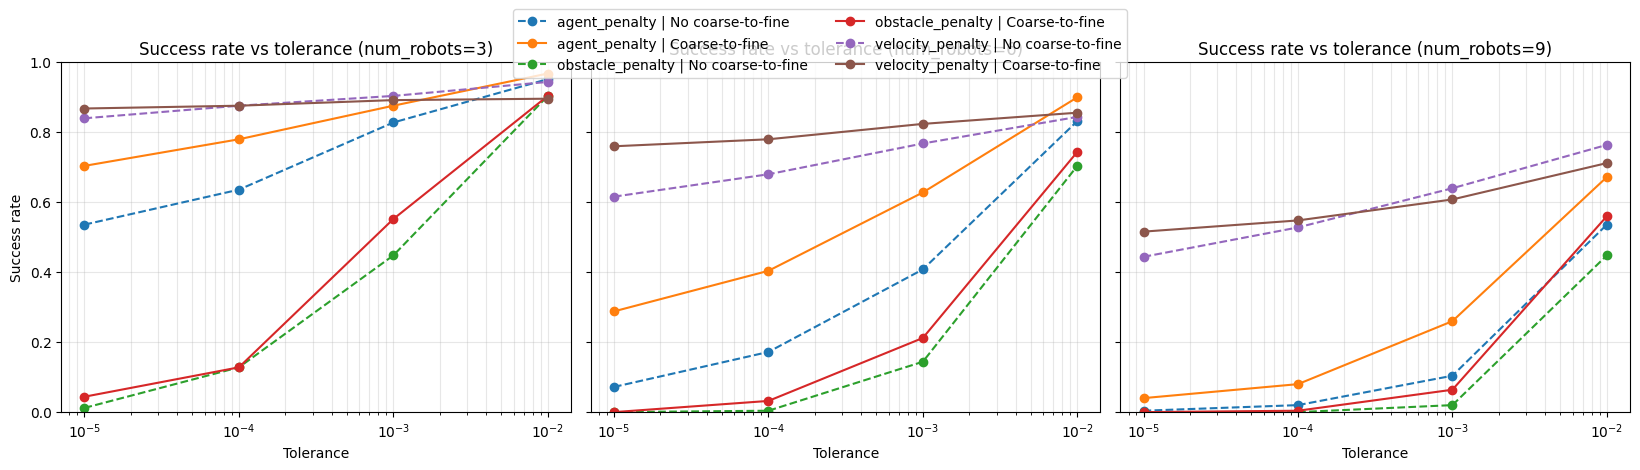

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# --- tolerances to sweep (example) ---
tolerances = np.array([1e-5, 1e-4, 1e-3, 1e-2], dtype=float)

# --- arrays ---
agent = np.asarray(data["agent_penalty"], dtype=float)
obst  = np.asarray(data["obstacle_penalty"], dtype=float)
ener  = np.asarray(data["energy"], dtype=float)
vel   = np.asarray(data["velocity_penalty"], dtype=float)

num_robots = np.asarray(data["num_robots"], dtype=int)
used_ctf   = np.asarray(data["used_coarse_to_fine"], dtype=bool)

metrics = {
    "agent_penalty": agent,
    "obstacle_penalty": obst,
    # "energy": ener,
    "velocity_penalty": vel,
}

metric_names = list(metrics.keys())
unique_nr = np.unique(num_robots)

# Plot settings: split by coarse-to-fine
split_by_ctf = True  # set False if you want to aggregate over ctf

# --- helper: success rate curve for one mask and one metric ---
def success_rate_curve(values, mask, tolerances):
    # success[t] = mean(values <= t) over masked entries
    if mask.sum() == 0:
        return np.full_like(tolerances, np.nan, dtype=float)
    v = values[mask]
    return np.array([(v <= t).mean() for t in tolerances], dtype=float)

# --- plotting ---
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(unique_nr),
    figsize=(5.5 * len(unique_nr), 4.5),
    sharey=True
)
if len(unique_nr) == 1:
    axes = [axes]

for ax, nr in zip(axes, unique_nr):
    mask_nr = (num_robots == nr)

    if split_by_ctf:
        masks = [
            ("No coarse-to-fine", mask_nr & (~used_ctf), "--"),
            ("Coarse-to-fine",    mask_nr & ( used_ctf), "-"),
        ]
    else:
        masks = [("All", mask_nr, "-")]

    for metric_name, values in metrics.items():
        for label, mask, ls in masks:
            y = success_rate_curve(values, mask, tolerances)
            ax.plot(tolerances, y, linestyle=ls, marker="o",
                    label=f"{metric_name} | {label}")

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_title(f"Success rate vs tolerance (num_robots={nr})")
    ax.set_xlabel("Tolerance")
    ax.grid(True, which="both", axis="both", alpha=0.3)

axes[0].set_ylabel("Success rate")
# One legend for the whole figure (can be large)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()


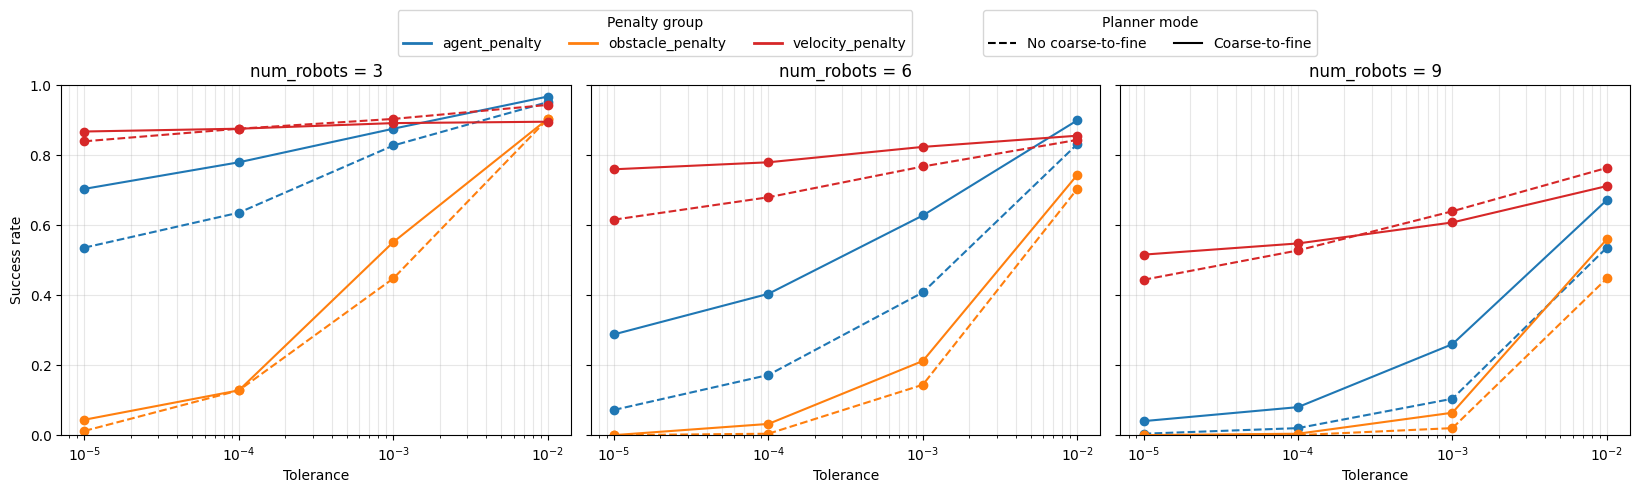

In [30]:
import matplotlib.lines as mlines

colors = {
    "agent_penalty": "C0",
    "obstacle_penalty": "C1",
    # "energy": "C2",
    "velocity_penalty": "C3",
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(unique_nr),
    figsize=(5.5 * len(unique_nr), 4.5),
    sharey=True
)
if len(unique_nr) == 1:
    axes = [axes]

for ax, nr in zip(axes, unique_nr):
    mask_nr = (num_robots == nr)

    for metric_name, values in metrics.items():
        color = colors[metric_name]

        # No coarse-to-fine
        y_no = success_rate_curve(values, mask_nr & (~used_ctf), tolerances)
        ax.plot(
            tolerances, y_no,
            linestyle="--", marker="o",
            color=color
        )

        # Coarse-to-fine
        y_yes = success_rate_curve(values, mask_nr & (used_ctf), tolerances)
        ax.plot(
            tolerances, y_yes,
            linestyle="-", marker="o",
            color=color
        )

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_title(f"num_robots = {nr}")
    ax.set_xlabel("Tolerance")
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("Success rate")

# --- Legend 1: penalty groups (colors) ---
penalty_handles = [
    mlines.Line2D([], [], color=c, lw=2, label=name)
    for name, c in colors.items()
]

# --- Legend 2: coarse-to-fine (line styles) ---
ctf_handles = [
    mlines.Line2D([], [], color="black", linestyle="--", label="No coarse-to-fine"),
    mlines.Line2D([], [], color="black", linestyle="-",  label="Coarse-to-fine"),
]

leg1 = fig.legend(
    handles=penalty_handles,
    loc="upper center",
    bbox_to_anchor=(0.4, 1.10),
    ncol=len(colors),
    title="Penalty group"
)

leg2 = fig.legend(
    handles=ctf_handles,
    loc="upper center",
    bbox_to_anchor=(0.7, 1.10),
    ncol=2,
    title="Planner mode"
)

plt.tight_layout()
plt.show()


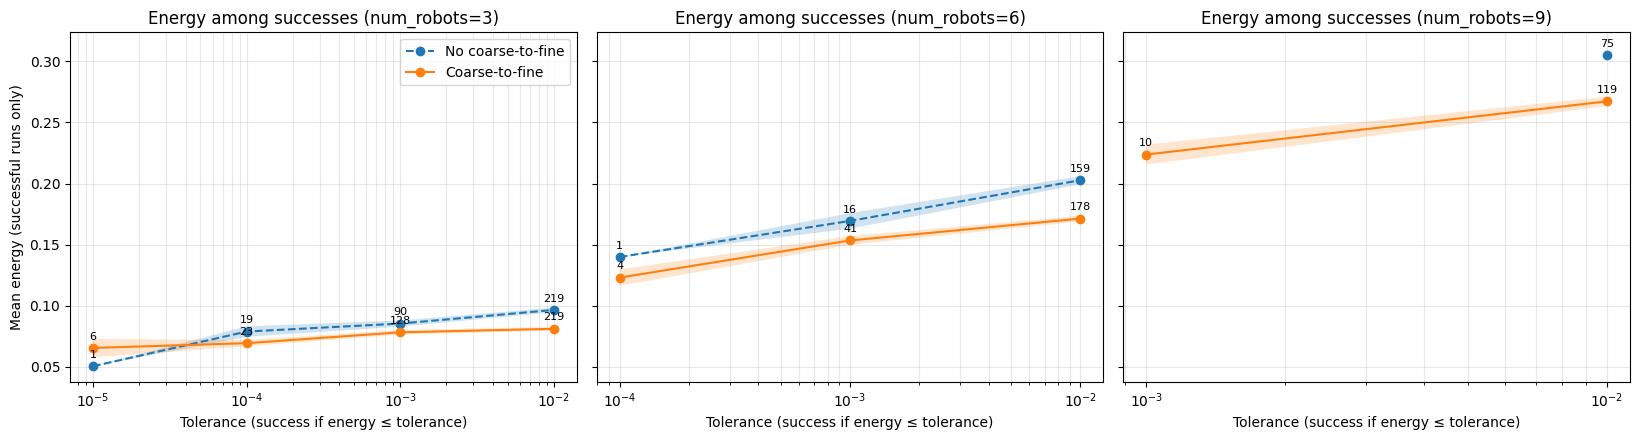

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Tolerances to sweep
tolerances = np.array([1e-5, 1e-4, 1e-3, 1e-2], dtype=float)

# Arrays
energy = np.asarray(data["energy"], dtype=float)
num_robots = np.asarray(data["num_robots"], dtype=int)
used_ctf = np.asarray(data["used_coarse_to_fine"], dtype=bool)

unique_nr = np.unique(num_robots)

def stats_over_successes(values, mask_base, tolerances):
    """
    For each tolerance t:
      successes = mask_base & (values <= t)
      return mean(values[successes]) and count(successes)
    """
    means = np.full_like(tolerances, np.nan, dtype=float)
    sems  = np.full_like(tolerances, np.nan, dtype=float)  # standard error
    counts = np.zeros_like(tolerances, dtype=int)

    for i, t in enumerate(tolerances):
        m = mask_base & (agent <= t) & (obst <= t) & (vel <= t)
        counts[i] = int(m.sum())
        if counts[i] > 0:
            v = values[m]
            means[i] = v.mean()
            # SEM (avoid divide-by-zero when n==1)
            sems[i] = v.std(ddof=1) / np.sqrt(counts[i]) if counts[i] > 1 else 0.0

    return means, sems, counts

fig, axes = plt.subplots(
    1, len(unique_nr),
    figsize=(5.5 * len(unique_nr), 4.5),
    sharey=True
)
if len(unique_nr) == 1:
    axes = [axes]

for ax, nr in zip(axes, unique_nr):
    mask_nr = (num_robots == nr)

    # No coarse-to-fine
    m_no, s_no, n_no = stats_over_successes(energy, mask_nr & (~used_ctf), tolerances)
    ax.plot(tolerances, m_no, linestyle="--", marker="o", label="No coarse-to-fine")
    ax.fill_between(tolerances, m_no - s_no, m_no + s_no, alpha=0.2)
    # annotate counts (optional)
    for t, y, n in zip(tolerances, m_no, n_no):
        if np.isfinite(y):
            ax.annotate(str(n), (t, y), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)

    # Coarse-to-fine
    m_yes, s_yes, n_yes = stats_over_successes(energy, mask_nr & (used_ctf), tolerances)
    ax.plot(tolerances, m_yes, linestyle="-", marker="o", label="Coarse-to-fine")
    ax.fill_between(tolerances, m_yes - s_yes, m_yes + s_yes, alpha=0.2)
    for t, y, n in zip(tolerances, m_yes, n_yes):
        if np.isfinite(y):
            ax.annotate(str(n), (t, y), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)

    ax.set_xscale("log")
    ax.set_title(f"Energy among successes (num_robots={nr})")
    ax.set_xlabel("Tolerance (success if energy ≤ tolerance)")
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("Mean energy (successful runs only)")
axes[0].legend()
plt.tight_layout()
plt.show()


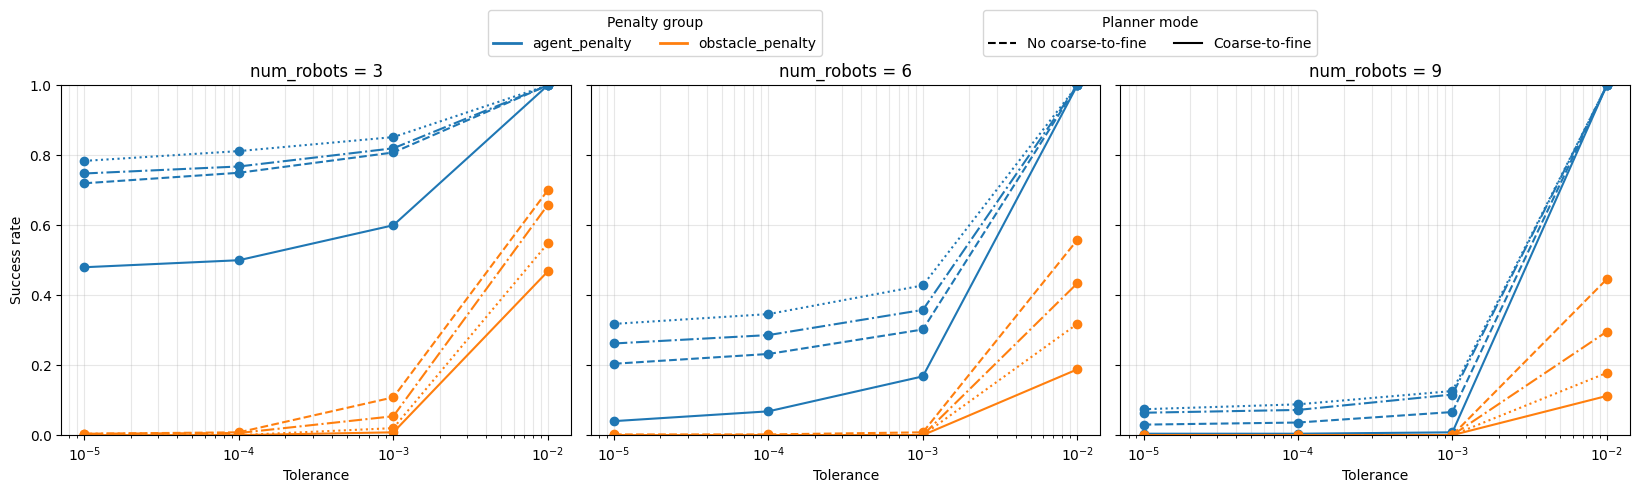

In [20]:
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Read all CSV files matching the pattern
csv_data = []
for csv_file in pathlib.Path("../").glob("experiment_results_*_num_steps_per_sigma=*.csv"):
    # Parse filename: experiment_results_{num_robots}_num_steps_per_sigma={steps}.csv
    parts = csv_file.stem.split("_")
    if not parts[6][6:].isdigit(): continue
    num_robots = int(parts[2])
    num_steps_per_sigma = int(parts[6].split("=")[1])
    
    df = pd.read_csv(csv_file)
    df["num_robots"] = num_robots
    df["num_steps_per_sigma"] = num_steps_per_sigma
    csv_data.append(df)

# Combine all data
all_data = pd.concat(csv_data, ignore_index=True)

# Convert to numpy arrays
agent_penalty = np.array(all_data["agent_agent_max_residual"]) ** 2
obstacle_penalty = np.array(all_data["agent_obstacle_max_residual"]) ** 2
# velocity_penalty = np.array(all_data["velocity_penalty"])
num_robots = np.array(all_data["num_robots"])
num_steps_per_sigma = np.array(all_data["num_steps_per_sigma"])

metrics = {
    "agent_penalty": agent_penalty,
    "obstacle_penalty": obstacle_penalty,
    # "velocity_penalty": velocity_penalty,
}

# Tolerances for success rate
tolerances = np.array([1e-5, 1e-4, 1e-3, 1e-2], dtype=float)
unique_nr = np.unique(num_robots)

# Success rate curve helper
def success_rate_curve(values, mask, tolerances):
    if mask.sum() == 0:
        return np.full_like(tolerances, np.nan, dtype=float)
    v = values[mask]
    return np.array([(v <= t).mean() for t in tolerances], dtype=float)

# Colors for each metric
colors = {
    "agent_penalty": "C0",
    "obstacle_penalty": "C1",
    # "velocity_penalty": "C3",
}

# Create plots
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(unique_nr),
    figsize=(5.5 * len(unique_nr), 4.5),
    sharey=True
)
if len(unique_nr) == 1:
    axes = [axes]

for ax, nr in zip(axes, unique_nr):
    mask_nr = (num_robots == nr)

    for metric_name, values in metrics.items():
        color = colors[metric_name]

        # No coarse-to-fine
        # y_no = success_rate_curve(values, mask_nr & (~used_ctf), tolerances)
        # ax.plot(
        #     tolerances, y_no,
        #     linestyle="--", marker="o",
        #     color=color
        # )

        # Coarse-to-fine
        for linestyle, num_steps_per_sigma_ in zip(["-", "--", "-.", ":"], [60, 120, 180, 240]):
            y_yes = success_rate_curve(values, mask_nr & (num_steps_per_sigma == num_steps_per_sigma_), tolerances)
            ax.plot(
                tolerances, y_yes,
                linestyle=linestyle, marker="o",
                color=color
            )

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_title(f"num_robots = {nr}")
    ax.set_xlabel("Tolerance")
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("Success rate")

# Legend 1: penalty groups (colors)
penalty_handles = [
    mlines.Line2D([], [], color=c, lw=2, label=name)
    for name, c in colors.items()
]

# Legend 2: coarse-to-fine (line styles)
ctf_handles = [
    mlines.Line2D([], [], color="black", linestyle="--", label="No coarse-to-fine"),
    mlines.Line2D([], [], color="black", linestyle="-",  label="Coarse-to-fine"),
]

leg1 = fig.legend(
    handles=penalty_handles,
    loc="upper center",
    bbox_to_anchor=(0.4, 1.10),
    ncol=len(colors),
    title="Penalty group"
)

leg2 = fig.legend(
    handles=ctf_handles,
    loc="upper center",
    bbox_to_anchor=(0.7, 1.10),
    ncol=2,
    title="Planner mode"
)

plt.tight_layout()
plt.show()

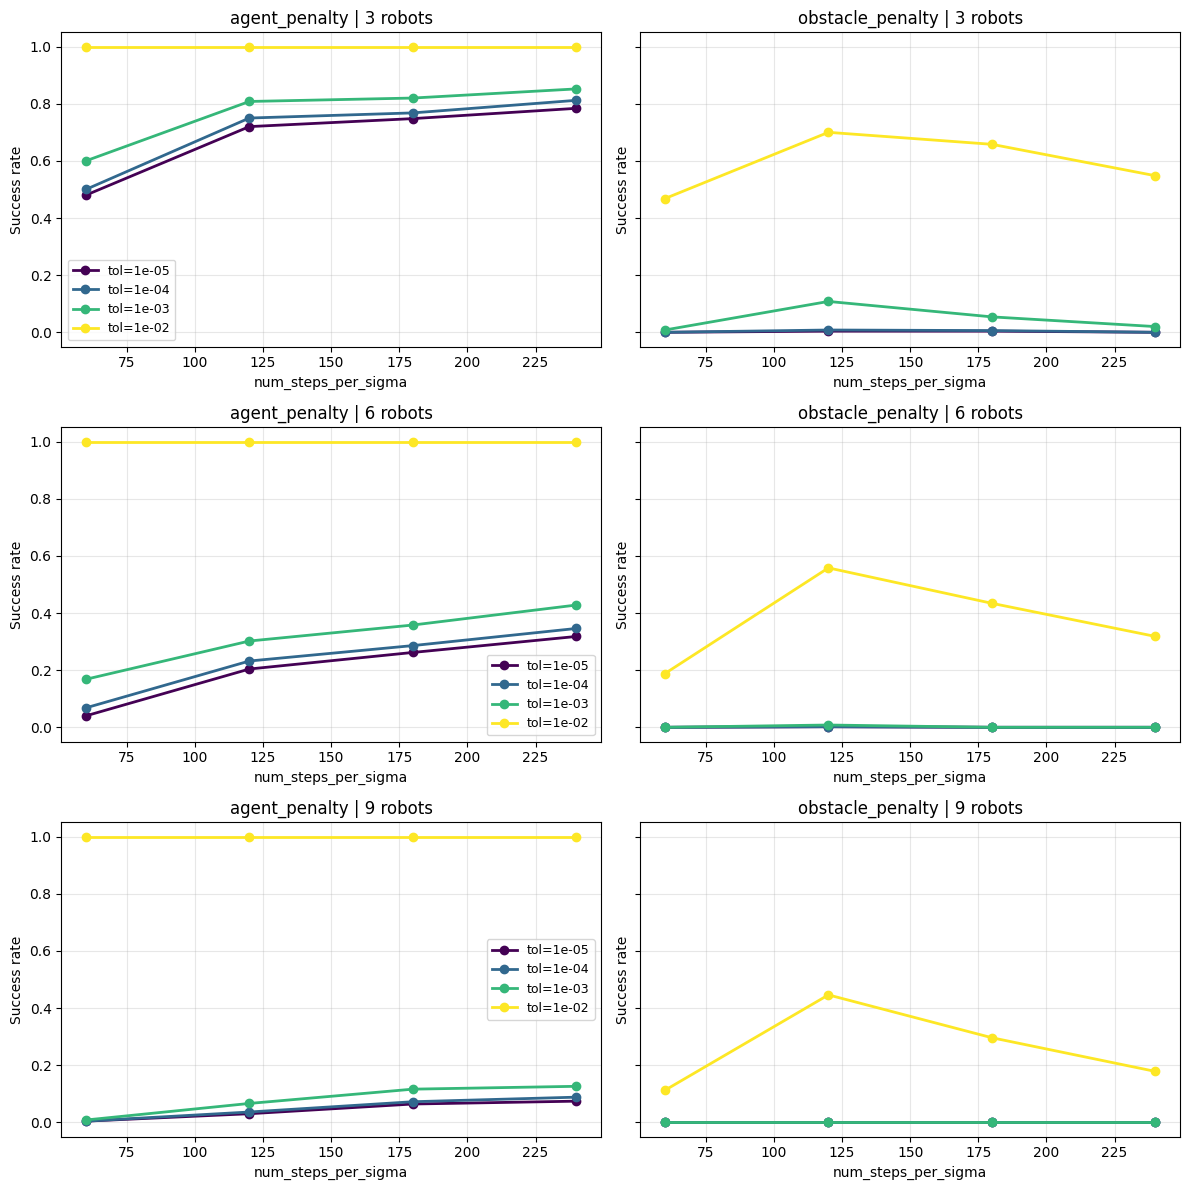

In [21]:
# Better visualization: show num_steps_per_sigma impact more intuitively
# X-axis: num_steps_per_sigma, Y-axis: success_rate, different lines for tolerances

unique_steps = np.sort(np.unique(num_steps_per_sigma))
tolerance_colors = plt.cm.viridis(np.linspace(0, 1, len(tolerances)))

fig, axes = plt.subplots(
    nrows=len(unique_nr),
    ncols=len(colors),
    figsize=(6 * len(colors), 4 * len(unique_nr)),
    sharey='row'
)
if len(unique_nr) == 1:
    axes = axes.reshape(1, -1)
if len(colors) == 1:
    axes = axes.reshape(-1, 1)

for i, nr in enumerate(unique_nr):
    mask_nr = (num_robots == nr)
    
    for j, (metric_name, values) in enumerate(metrics.items()):
        ax = axes[i, j] if axes.ndim > 1 else axes[j]
        
        # For each tolerance, plot success rate vs num_steps_per_sigma
        for tol_idx, tol in enumerate(tolerances):
            success_rates = []
            for steps in unique_steps:
                mask = mask_nr & (num_steps_per_sigma == steps)
                success_rate = (values[mask] <= tol).mean()
                success_rates.append(success_rate)
            
            ax.plot(
                unique_steps, success_rates,
                marker='o', linewidth=2,
                color=tolerance_colors[tol_idx],
                label=f'tol={tol:.0e}'
            )
        
        ax.set_xlabel('num_steps_per_sigma')
        ax.set_ylabel('Success rate')
        ax.set_title(f'{metric_name} | {nr} robots')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
        if j == 0:
            ax.legend(fontsize=9)

plt.tight_layout()
plt.show()